# Data Validation

Validation of the first 700 days of 2026 Algothon price data (the development period). Days 701–1000 are reserved for final testing. This notebook checks the instrument universe, validates prices, calculates daily returns and highlights observations to investigate before modelling.

In [72]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.float_format', '{:,.4f}'.format)

# Works whether Jupyter is started from the repository root or notebooks/
repo_root = Path.cwd()
if not (repo_root / 'backtester').exists():
    repo_root = repo_root.parent

data_dir = repo_root / 'backtester' / 'data' / '2026'
prices_path = data_dir / 'prices.txt'
tickers_path = data_dir / 'tickers.txt'

TRAIN_DAYS = 700
prices_full = pd.read_csv(prices_path, sep=r'\s+')
prices = prices_full.iloc[:TRAIN_DAYS].copy()
tickers = pd.read_csv(tickers_path, header=None, names=['ticker'])['ticker'].tolist()

assert len(prices_full) >= TRAIN_DAYS, 'Not enough observations for the train period'
assert prices.columns.tolist() == tickers, 'Price columns and tickers.txt do not match'
prices.shape

(700, 51)

## Instrument universe

Competition universe should contain 51 instruments: ALGO at index 0 and 50 non-ALGO stocks.

In [73]:
expected_n_instruments = 51
algo_index = 0

instrument_check = pd.DataFrame({
    'check': ['Number of instruments', 'Instrument 0'],
    'expected': [expected_n_instruments, 'ALGO'],
    'observed': [prices.shape[1], prices.columns[algo_index]],
})
instrument_check['passed'] = instrument_check['expected'] == instrument_check['observed']
display(instrument_check)

assert prices.shape[1] == expected_n_instruments
assert prices.columns[algo_index] == 'ALGO'

pd.DataFrame({'index': range(len(tickers)), 'ticker': tickers}).head(10)

,check,expected,observed,passed
0,Number of instruments,51,51,True
1,Instrument 0,ALGO,ALGO,True


,index,ticker
0,0,ALGO
1,1,AENO
2,2,LSST
3,3,SRNA
4,4,ELLT
5,5,AMRP
6,6,OTCS
7,7,HETT
8,8,HUXZ
9,9,DUCT


## Missing values and price ranges

In [74]:
validation = pd.DataFrame({
    'missing_values': prices.isna().sum(),
    'non_positive_prices': (prices <= 0).sum(),
    'min_price': prices.min(),
    'max_price': prices.max(),
    'first_price': prices.iloc[0],
    'last_price': prices.iloc[-1],
})
validation['price_range'] = validation['max_price'] - validation['min_price']
validation['total_return_pct'] = (validation['last_price'] / validation['first_price'] - 1) * 100

print(f'Days: {len(prices):,}')
print(f'Total missing values: {validation.missing_values.sum():,}')
print(f'Total non-positive prices: {validation.non_positive_prices.sum():,}')
display(validation.sort_values('total_return_pct'))

assert validation.missing_values.sum() == 0
assert validation.non_positive_prices.sum() == 0

Days: 700
Total missing values: 0
Total non-positive prices: 0


,missing_values,non_positive_prices,min_price,max_price,first_price,last_price,price_range,total_return_pct
SPLZ,0,0,27.9400,130.4000,104.3300,36.5500,102.4600,-64.9669
HRND,0,0,6.0000,40.3900,24.0700,9.0100,34.3900,-62.5675
SRNA,0,0,53.6200,166.2600,134.2300,54.8200,112.6400,-59.1597
AETS,0,0,17.2700,48.6800,42.9700,17.6200,31.4100,-58.9946
DIHO,0,0,5.5000,14.2200,12.4700,5.7200,8.7200,-54.1299
FARS,0,0,31.2500,66.4300,66.4300,33.8500,35.1800,-49.0441
BLBT,0,0,25.2600,56.1800,52.2300,26.7300,30.9200,-48.8225
MHRM,0,0,7.3300,22.4100,22.4100,11.7000,15.0800,-47.7912
RCRI,0,0,24.0500,66.1700,54.6400,29.2100,42.1200,-46.5410
EAFC,0,0,14.9800,46.4200,45.0800,24.4000,31.4400,-45.8740


## Daily returns

Simple returns are used below: $r_t = P_t / P_{t-1} - 1$. The first row is undefined because there is no preceding price.

In [75]:
returns = prices.pct_change(fill_method=None)

return_summary = returns.agg(['mean', 'std', 'min', 'max']).T
return_summary['mean_pct'] = return_summary['mean'] * 100
return_summary['volatility_pct'] = return_summary['std'] * 100
return_summary[['mean_pct', 'volatility_pct', 'min', 'max']].sort_values('volatility_pct', ascending=False)

,mean_pct,volatility_pct,min,max
MMBT,0.2896,4.0869,-0.1237,0.1460
EELT,0.1256,3.3650,-0.1067,0.1149
AETS,-0.0719,3.3382,-0.0867,0.1255
RCRI,-0.0344,3.3241,-0.0902,0.1047
NAYO,-0.0230,3.2719,-0.0901,0.1103
RTTH,-0.0260,3.2339,-0.0910,0.1124
CTGI,0.1024,3.0233,-0.0981,0.0858
ULXY,0.0775,2.9860,-0.0841,0.1128
HRND,-0.0982,2.9084,-0.0982,0.0854
AMRP,0.0189,2.7799,-0.0842,0.0876


## Daily-return distribution
Each bar counts how often a one-day return occurred across every instrument and day in the 600-day development sample.

Combines 599 daily returns × 51 instruments = 30,549 observations.


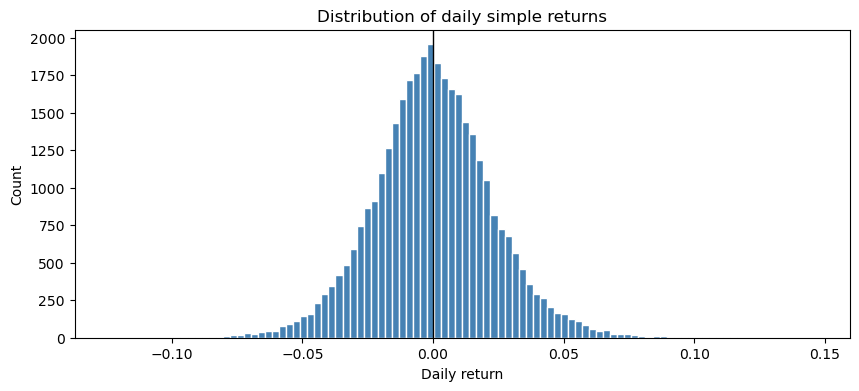

In [76]:
all_daily_returns = returns.to_numpy().ravel()
all_daily_returns = all_daily_returns[np.isfinite(all_daily_returns)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_daily_returns, bins=100, color='steelblue', edgecolor='white')
ax.set(title='Distribution of daily simple returns', xlabel='Daily return', ylabel='Count')
ax.axvline(0, color='black', linewidth=1)
plt.show()

**Notes / interpretation:** 
* Most returns should cluster near zero
* Long tails or isolated extreme moves should be checked

## Normalized price paths
Every instrument starts at 100, making their relative price changes directly comparable.

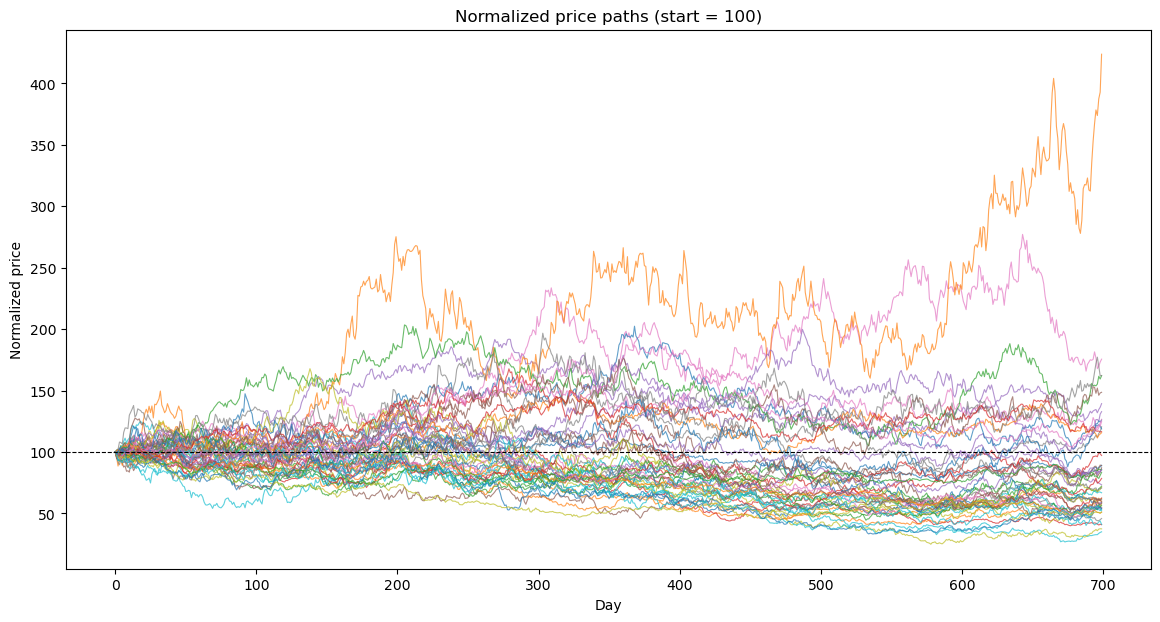

In [77]:
normalized_prices = prices.div(prices.iloc[0]).mul(100)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(normalized_prices.index, normalized_prices, linewidth=0.8, alpha=0.7)
ax.set(title='Normalized price paths (start = 100)', xlabel='Day', ylabel='Normalized price')
ax.axhline(100, color='black', linewidth=0.8, linestyle='--')
plt.show()

#### Five highest and five lowest ending normalized price levels

In [78]:
path_summary = pd.DataFrame({
    'ending_level': normalized_prices.iloc[-1],
    'minimum_level': normalized_prices.min(),
    'maximum_level': normalized_prices.max(),
})
path_summary['total_return_pct'] = path_summary['ending_level'] - 100

extreme_paths = pd.concat([
    path_summary.nlargest(5, 'ending_level'),
    path_summary.nsmallest(5, 'ending_level'),
])
display(extreme_paths.style.format('{:,.1f}'))

,ending_level,minimum_level,maximum_level,total_return_pct
MMBT,423.8,88.6,423.8,323.8
OTCS,175.5,85.9,277.1,75.5
EELT,162.2,100.0,196.7,62.2
MDGI,162.1,92.1,203.4,62.1
CTGI,148.6,89.0,176.5,48.6
SPLZ,35.0,26.8,125.0,-65.0
HRND,37.4,24.9,167.8,-62.6
SRNA,40.8,39.9,123.9,-59.2
AETS,41.0,40.2,113.3,-59.0
DIHO,45.9,44.1,114.0,-54.1


**Notes / interpretation**

- Development-period price paths are highly dispersed: MMBT and OTCS finish near 236 and 235, while HRND finishes near 28.
- HRND, SPLZ, MHRM, and EAFC each finish below 38, showing materially different price paths across instruments.

## Daily-return volatility by instrument
Higher bars indicate instruments with larger typical one-day price moves.

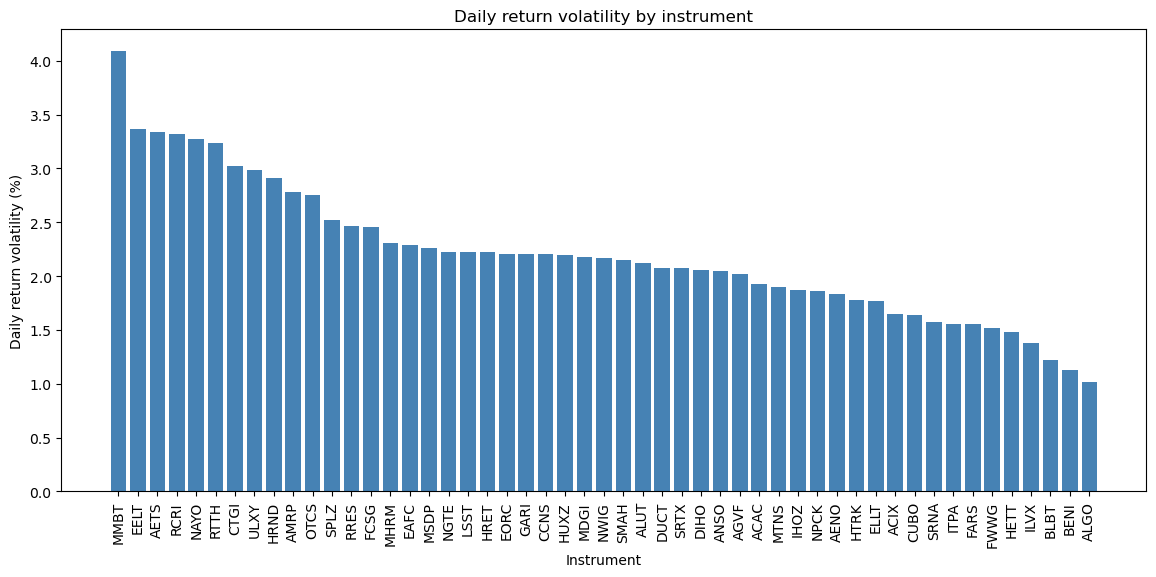

In [79]:
volatility_pct = returns.std().sort_values(ascending=False).mul(100)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(volatility_pct.index, volatility_pct, color='steelblue')
ax.set(title='Daily return volatility by instrument', xlabel='Instrument', ylabel='Daily return volatility (%)')
ax.tick_params(axis='x', rotation=90)
plt.show()

#### Ten highest daily-return volatilities, plus ALGO

In [80]:
volatility_summary = volatility_pct.rename('daily_volatility_pct').to_frame()
top_volatility = pd.concat([
    volatility_summary.head(10),
    volatility_summary.loc[['ALGO']],
]).loc[lambda frame: ~frame.index.duplicated()]
display(top_volatility.style.format('{:.2f}%'))

,daily_volatility_pct
MMBT,4.09%
EELT,3.36%
AETS,3.34%
RCRI,3.32%
NAYO,3.27%
RTTH,3.23%
CTGI,3.02%
ULXY,2.99%
HRND,2.91%
AMRP,2.78%


**Notes / interpretation**

- MMBT has the largest development-period daily-return volatility (4.09%), followed by EELT (3.41%) and RCRI (3.35%).
- ALGO is comparatively low-volatility at 0.99%, so the highest bars are likely to drive a disproportionate share of portfolio risk and extreme-return observations.

## Extreme return observations

Identify the largest absolute one-day returns. These may reflect genuine market moves, regime changes or data-quality issues and should be investigated before modelling.

In [81]:
long_returns = (
    returns.rename_axis('day')
    .reset_index()
    .melt(id_vars='day', var_name='ticker', value_name='return')
    .dropna()
)

unusual_moves = (
    long_returns.assign(abs_return=lambda frame: frame['return'].abs())
    .nlargest(20, 'abs_return')
    .assign(return_pct=lambda frame: frame['return'] * 100)
    [['day', 'ticker', 'return_pct', 'abs_return']]
)
display(unusual_moves.style.format({'return_pct': '{:+.2f}%', 'abs_return': '{:.4f}'}))

,day,ticker,return_pct,abs_return
15171,471,MMBT,+14.60%,0.1460
14872,172,MMBT,+13.28%,0.1328
27405,105,AETS,+12.55%,0.1255
14766,66,MMBT,-12.37%,0.1237
14987,287,MMBT,+11.88%,0.1188
15013,313,MMBT,+11.50%,0.1150
26243,343,EELT,+11.49%,0.1149
15103,403,MMBT,+11.43%,0.1143
28092,92,ULXY,+11.28%,0.1128
12823,223,RTTH,+11.24%,0.1124


## Summary of findings

* The dataset is structurally valid
    * 600 development days, 51 instruments and ALGO correctly located at index 0
    * There are no missing or non-positive prices
* Stock price paths differ substantially across instruments: some rose strongly, while others declined sharply
    * MMBT ends near 236 (from 100), while HRND ends near 28
* MMBT is the most volatile instrument (4.09% daily volatility) and produces several of the largest one-day moves
* ALGO is comparatively stable (1.00%).

### Next research

* Inspect the largest moves, especially in MMBT, to understand which instruments and periods drive the dataset’s highest volatility
* Test return relationships, autocorrelation, and correlations using rolling, time-respecting windows